# LogHAR Model on the MHAR Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the LogHAR model on the $\mathcal{M}_{\mathrm{HAR}}$ feature set for the EURO STOXX 50 index. Following the same benchmark workflow as the HAR notebook, we estimate the model on a rolling window and evaluate one-day-ahead forecasts using the Mean Squared Error (MSE). The model is estimated in log space with dependent variable `logRV_target` and predictors `logRVD`, `logRVW`, and `logRVM`, after which forecasts and realized values are converted back into levels so the results are directly comparable to the HAR benchmark.


## 1.1 Loading Data


In [1]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
print("\nLogHAR columns available:")
print(MALL[["logRVD", "logRVW", "logRVM", "logRV_target"]].head())


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0

LogHAR columns available:
              logRVD    logRVW    logRVM  logRV_target
Date                                                  
1999-01-05 -9.462355 -9.288024 -8.958306     -9.760055
1999-01-06 -9.760055 -9.290171 -9.005038     -8.877543
1999-01-07 -8.877543 -9.192627 -9.023153     -9.130603
1999-01-08 -9.130603 -9.148418 -9.097084     -8.702667
1999-01-11 -8.702667 -9.116188 -9.115384     -9.067553


## 2. Data Split


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%) in chronological order. The rolling estimation window used for out-of-sample forecasting is the combined training and validation sample, matching the HAR benchmark notebook.


In [2]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. LogHAR Model


The LogHAR benchmark is estimated in log space as

$$\log(RV_{t+1}) = \beta_0 + \beta_d \log(RV_t) + \beta_w \log(\overline{RV}^{(w)}_t) + \beta_m \log(\overline{RV}^{(m)}_t) + \varepsilon_{t+1}$$

where the target is `logRV_target` and the predictors are the log-transformed MHAR variables available in `MALL.csv`. After forecasting in log space, both forecasts and realized values are exponentiated back to realized-variance levels for evaluation and plotting.


### 3.2 Feature Set Construction


In [3]:
# Define target and feature set for LogHAR on MHAR
y = MALL["logRV_target"]
X_MHAR = MALL[["logRVD", "logRVW", "logRVM"]]

print("Target variable: logRV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())


Target variable: logRV_target
Predictors: ['logRVD', 'logRVW', 'logRVM']

First few rows:
            logRV_target    logRVD    logRVW    logRVM
Date                                                  
1999-01-05     -9.760055 -9.462355 -9.288024 -8.958306
1999-01-06     -8.877543 -9.760055 -9.290171 -9.005038
1999-01-07     -9.130603 -8.877543 -9.192627 -9.023153
1999-01-08     -8.702667 -9.130603 -9.148418 -9.097084
1999-01-11     -9.067553 -8.702667 -9.116188 -9.115384


### 3.3 Rolling Window Estimation and Forecasting


In [4]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_LogHAR = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values

    # OLS estimation in log space
    model = LinearRegression()
    model.fit(X_window, y_window)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]

    forecasts_LogHAR.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_LogHAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation


Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using the Mean Squared Error (MSE). For comparability with the HAR benchmark, LogHAR forecasts are first generated in log space and then converted back to realized-variance levels before metrics are computed.


In [5]:
# Collect results in levels for direct comparison with HAR
results_LogHAR = pd.DataFrame({
    "RV_actual": np.exp(y.loc[dates_test].values),
    "RV_forecast": np.exp(forecasts_LogHAR)
}, index=dates_test)

# Compute out-of-sample MSE
mse_LogHAR = np.mean((results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (LogHAR): {mse_LogHAR:.6e}")
print(f"\nFirst few level forecasts vs actuals:")
print(results_LogHAR.head(10).to_string())


Out-of-sample MSE (LogHAR): 3.867638e-01

First few forecasts vs actuals:
            logRV_actual  logRV_forecast
2016-04-21     -9.595721       -9.040056
2016-04-22     -9.447785       -9.224509
2016-04-25     -9.433342       -9.365698
2016-04-26    -10.005519       -9.337419
2016-04-27     -8.762147       -9.543924
2016-04-28     -8.425464       -9.171655
2016-04-29     -9.349450       -8.928978
2016-05-02     -9.138131       -9.181466
2016-05-03     -9.126966       -9.120773
2016-05-04     -9.208693       -9.072834


### 3.4.1 Save Forecasts


In [6]:
import os

# Save LogHAR forecasts to CSV for comparison with other models
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

# Save forecasts
results_LogHAR.to_csv(os.path.join(forecast_path, "forecasts_LogHAR.csv"))

# Save MSE summary
mse_summary_LogHAR = pd.DataFrame({
    "Model": ["LogHAR"],
    "MSE":   [mse_LogHAR],
    "RMSE":  [np.sqrt(mse_LogHAR)],
    "MAE":   [np.mean(np.abs(results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"])],
}).set_index("Model")

mse_summary_LogHAR.to_csv(os.path.join(forecast_path, "mse_summary_LogHAR.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_LogHAR.csv ({len(results_LogHAR)} rows)")
print(f"  - mse_summary_LogHAR.csv")
print(f"\nLogHAR MSE: {mse_LogHAR:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_LogHAR.csv (1099 rows)
  - mse_summary_LogHAR.csv

LogHAR MSE: 3.867638e-01


## 4. Results


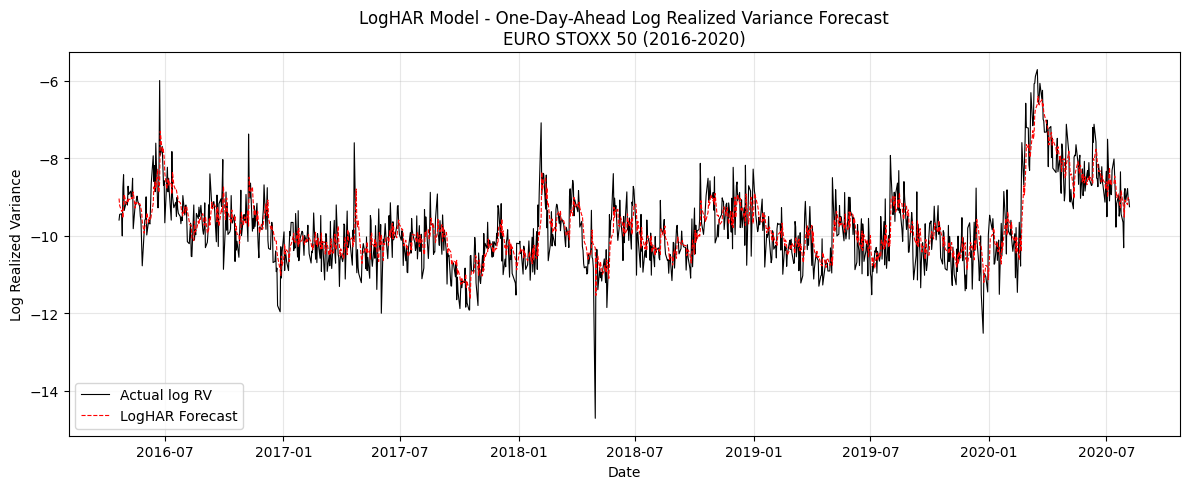


Summary of forecast errors:
Mean error:  -4.602210e-02
RMSE:        6.219034e-01
MAE:         4.754728e-01


In [7]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability and direct comparison with HAR
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_LogHAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_LogHAR["RV_forecast"] * 252) * 100
}, index=results_LogHAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="LogHAR Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("LogHAR Model - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_LogHAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")


### 4.2 Forecast Performance Summary


In [8]:
from IPython.display import display

# Summary table of forecast performance
performance = pd.DataFrame({
    "Model": ["LogHAR"],
    "MSE":   [mse_LogHAR],
    "RMSE":  [np.sqrt(mse_LogHAR)],
    "MAE":   [errors.abs().mean()],
    "Mean Error": [errors.mean()],
    "Relative MSE": [1.0]
}).set_index("Model")

styled_performance = (
    performance.style
    .set_caption(
        "Table 3: Out-of-Sample Forecast Performance - LogHAR Model\n"
        f"EURO STOXX 50 Test Period: {dates_test[0].date()} to {dates_test[-1].date()} ({n_test} observations)"
    )
    .format({
        "MSE":         "{:.6e}",
        "RMSE":        "{:.6e}",
        "MAE":         "{:.6e}",
        "Mean Error":  "{:.6e}",
        "Relative MSE": "{:.4f}"
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [
             ("font-size", "12px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding-bottom", "8px"),
             ("color", "black"),
             ("caption-side", "top"),
         ]},
        {"selector": "thead tr th",
         "props": [
             ("background-color", "white"),
             ("color", "black"),
             ("font-size", "11px"),
             ("text-align", "center"),
             ("padding", "6px 10px"),
             ("border-top", "2px solid black"),
             ("border-bottom", "1px solid black"),
             ("font-weight", "bold"),
         ]},
        {"selector": "tbody tr th",
         "props": [
             ("font-size", "11px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding", "4px 10px"),
             ("color", "black"),
             ("background-color", "white"),
             ("border-right", "1px solid black"),
         ]},
        {"selector": "tbody tr td",
         "props": [
             ("font-size", "11px"),
             ("text-align", "right"),
             ("padding", "4px 10px"),
             ("background-color", "white"),
             ("color", "black"),
         ]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th",
         "props": [("border-bottom", "2px solid black")]},
        {"selector": "table",
         "props": [
             ("border-collapse", "collapse"),
             ("width", "100%"),
         ]},
        {"selector": "td, th",
         "props": [
             ("border-left", "none"),
             ("border-right", "none"),
         ]},
    ])
)

display(styled_performance)


,MSE,RMSE,MAE,Mean Error,Relative MSE
Model,,,,,
LogHAR,3.867638e-01,6.219034e-01,4.754728e-01,-4.602210e-02,1.0000
